# MNIST Handwritten Digit Classification using PyTorch

## Objectives
- Build and train a neural network using PyTorch
- Compare different network architectures
- Compare different optimizers
- Analyze overfitting and underfitting
- Apply regularization techniques
- Implement early stopping
- Evaluate performance on test data


## Step 1: Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Step 2: Load and Preprocess Dataset

In [2]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Split training into train and validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.91MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.86MB/s]


## Step 3: Define Base Model

In [3]:
class BaseModel(nn.Module):
    def __init__(self):
        super(BaseModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


## Step 4: Training Function (With Early Stopping)

In [4]:
def train_model(model, optimizer, epochs=20, patience=3):

    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float('inf')
    counter = 0

    for epoch in range(epochs):

        # Training
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        total_val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = total_val_loss / len(val_loader)
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
              f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    return train_losses, val_losses, train_accs, val_accs


## Step 5: Plot Function

In [5]:
def plot_curves(train_losses, val_losses, train_accs, val_accs, title):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.title(f"{title} - Loss")
    plt.legend(["Train", "Validation"])

    plt.subplot(1,2,2)
    plt.plot(train_accs)
    plt.plot(val_accs)
    plt.title(f"{title} - Accuracy")
    plt.legend(["Train", "Validation"])

    plt.show()


## Step 6: Architecture Comparison

#### Simple Model (Underfitting)

In [6]:
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 32)
        self.fc2 = nn.Linear(32, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


#### Complex Model (Overfitting)

In [7]:
class ComplexModel(nn.Module):
    def __init__(self):
        super(ComplexModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x


#### Train and Plot:


Training SimpleModel
Epoch 1: Train Loss=0.4181, Val Loss=0.2554, Train Acc=0.8883, Val Acc=0.9305
Epoch 2: Train Loss=0.2248, Val Loss=0.2039, Train Acc=0.9350, Val Acc=0.9423
Epoch 3: Train Loss=0.1762, Val Loss=0.1700, Train Acc=0.9486, Val Acc=0.9491
Epoch 4: Train Loss=0.1454, Val Loss=0.1511, Train Acc=0.9576, Val Acc=0.9576
Epoch 5: Train Loss=0.1256, Val Loss=0.1387, Train Acc=0.9630, Val Acc=0.9604
Epoch 6: Train Loss=0.1093, Val Loss=0.1355, Train Acc=0.9671, Val Acc=0.9601
Epoch 7: Train Loss=0.0992, Val Loss=0.1340, Train Acc=0.9700, Val Acc=0.9606
Epoch 8: Train Loss=0.0887, Val Loss=0.1233, Train Acc=0.9728, Val Acc=0.9643
Epoch 9: Train Loss=0.0818, Val Loss=0.1236, Train Acc=0.9746, Val Acc=0.9637
Epoch 10: Train Loss=0.0751, Val Loss=0.1290, Train Acc=0.9774, Val Acc=0.9618
Epoch 11: Train Loss=0.0686, Val Loss=0.1238, Train Acc=0.9790, Val Acc=0.9654
Early stopping triggered.


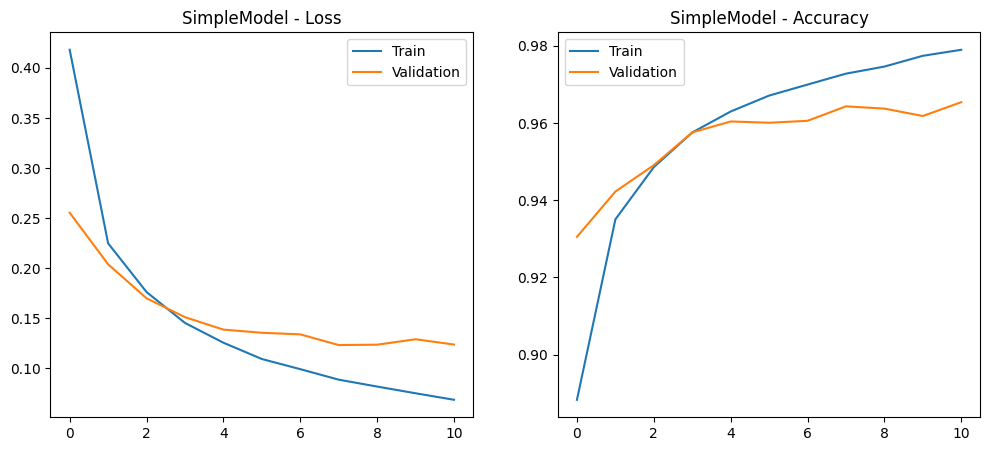


Training BaseModel
Epoch 1: Train Loss=0.3177, Val Loss=0.1686, Train Acc=0.9072, Val Acc=0.9493
Epoch 2: Train Loss=0.1380, Val Loss=0.1424, Train Acc=0.9577, Val Acc=0.9579
Epoch 3: Train Loss=0.0929, Val Loss=0.0994, Train Acc=0.9706, Val Acc=0.9710
Epoch 4: Train Loss=0.0691, Val Loss=0.0916, Train Acc=0.9778, Val Acc=0.9736
Epoch 5: Train Loss=0.0531, Val Loss=0.0936, Train Acc=0.9830, Val Acc=0.9731
Epoch 6: Train Loss=0.0415, Val Loss=0.0869, Train Acc=0.9866, Val Acc=0.9747
Epoch 7: Train Loss=0.0334, Val Loss=0.0850, Train Acc=0.9889, Val Acc=0.9765
Epoch 8: Train Loss=0.0269, Val Loss=0.1042, Train Acc=0.9918, Val Acc=0.9741
Epoch 9: Train Loss=0.0256, Val Loss=0.0972, Train Acc=0.9916, Val Acc=0.9769
Epoch 10: Train Loss=0.0197, Val Loss=0.1062, Train Acc=0.9930, Val Acc=0.9755
Early stopping triggered.


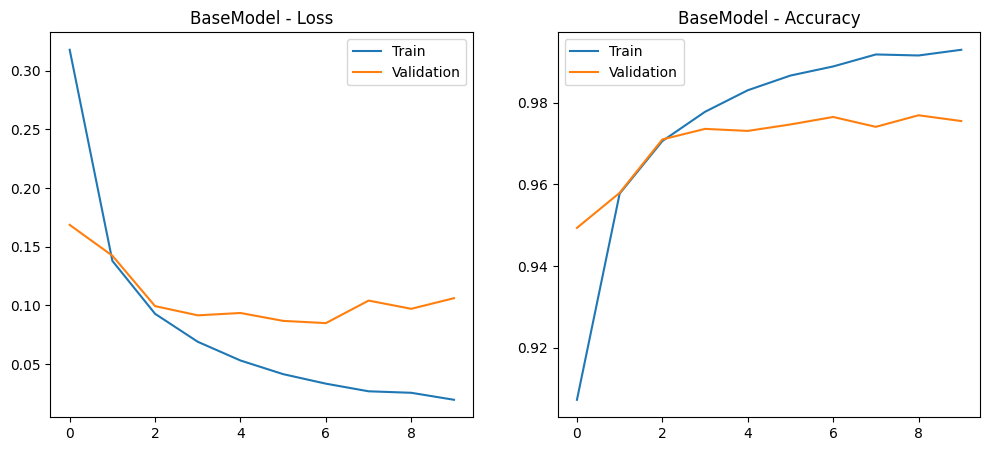


Training ComplexModel
Epoch 1: Train Loss=0.2850, Val Loss=0.1372, Train Acc=0.9151, Val Acc=0.9581
Epoch 2: Train Loss=0.1112, Val Loss=0.1088, Train Acc=0.9652, Val Acc=0.9674
Epoch 3: Train Loss=0.0765, Val Loss=0.0945, Train Acc=0.9763, Val Acc=0.9717
Epoch 4: Train Loss=0.0557, Val Loss=0.1094, Train Acc=0.9821, Val Acc=0.9702
Epoch 5: Train Loss=0.0454, Val Loss=0.0910, Train Acc=0.9854, Val Acc=0.9764
Epoch 6: Train Loss=0.0404, Val Loss=0.0864, Train Acc=0.9875, Val Acc=0.9755
Epoch 7: Train Loss=0.0282, Val Loss=0.0932, Train Acc=0.9911, Val Acc=0.9769
Epoch 8: Train Loss=0.0270, Val Loss=0.0906, Train Acc=0.9915, Val Acc=0.9771
Epoch 9: Train Loss=0.0239, Val Loss=0.0845, Train Acc=0.9918, Val Acc=0.9778
Epoch 10: Train Loss=0.0194, Val Loss=0.1017, Train Acc=0.9940, Val Acc=0.9739
Epoch 11: Train Loss=0.0198, Val Loss=0.1141, Train Acc=0.9937, Val Acc=0.9747
Epoch 12: Train Loss=0.0191, Val Loss=0.0956, Train Acc=0.9939, Val Acc=0.9780
Early stopping triggered.


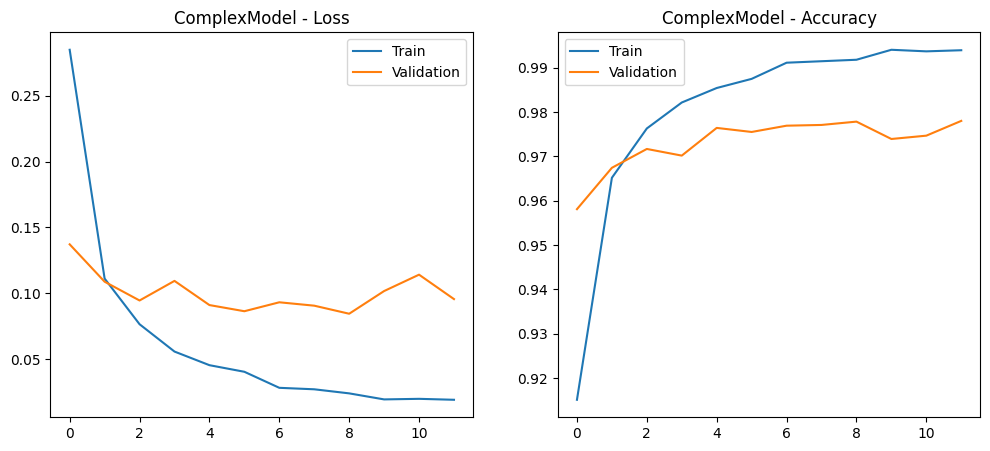

In [8]:
for model_class in [SimpleModel, BaseModel, ComplexModel]:
    print(f"\nTraining {model_class.__name__}")
    model = model_class()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    results = train_model(model, optimizer)
    plot_curves(*results, model_class.__name__)


## Step 7: Optimizer Comparison


Training with SGD
Epoch 1: Train Loss=1.3693, Val Loss=0.5257, Train Acc=0.6503, Val Acc=0.8552
Epoch 2: Train Loss=0.4261, Val Loss=0.3713, Train Acc=0.8787, Val Acc=0.8954
Epoch 3: Train Loss=0.3394, Val Loss=0.3181, Train Acc=0.9020, Val Acc=0.9087
Epoch 4: Train Loss=0.2998, Val Loss=0.2903, Train Acc=0.9135, Val Acc=0.9197
Epoch 5: Train Loss=0.2702, Val Loss=0.2640, Train Acc=0.9224, Val Acc=0.9267
Epoch 6: Train Loss=0.2467, Val Loss=0.2396, Train Acc=0.9292, Val Acc=0.9328
Epoch 7: Train Loss=0.2253, Val Loss=0.2219, Train Acc=0.9350, Val Acc=0.9385
Epoch 8: Train Loss=0.2068, Val Loss=0.2057, Train Acc=0.9404, Val Acc=0.9418
Epoch 9: Train Loss=0.1902, Val Loss=0.1993, Train Acc=0.9455, Val Acc=0.9448
Epoch 10: Train Loss=0.1757, Val Loss=0.1804, Train Acc=0.9501, Val Acc=0.9513
Epoch 11: Train Loss=0.1629, Val Loss=0.1690, Train Acc=0.9535, Val Acc=0.9532
Epoch 12: Train Loss=0.1516, Val Loss=0.1625, Train Acc=0.9566, Val Acc=0.9542
Epoch 13: Train Loss=0.1418, Val Loss=0.15

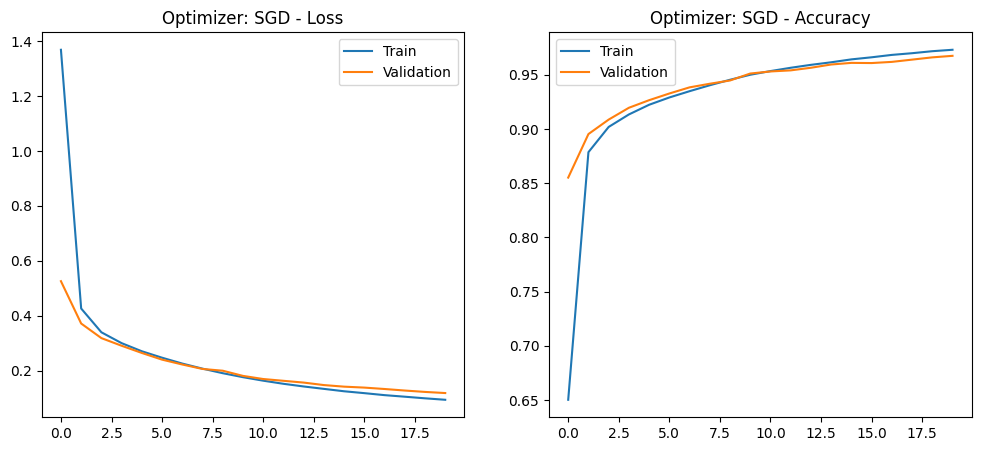


Training with RMSprop
Epoch 1: Train Loss=0.2707, Val Loss=0.1818, Train Acc=0.9182, Val Acc=0.9400
Epoch 2: Train Loss=0.1211, Val Loss=0.1152, Train Acc=0.9633, Val Acc=0.9662
Epoch 3: Train Loss=0.0833, Val Loss=0.0968, Train Acc=0.9746, Val Acc=0.9708
Epoch 4: Train Loss=0.0612, Val Loss=0.0882, Train Acc=0.9808, Val Acc=0.9742
Epoch 5: Train Loss=0.0487, Val Loss=0.0897, Train Acc=0.9842, Val Acc=0.9754
Epoch 6: Train Loss=0.0382, Val Loss=0.0866, Train Acc=0.9879, Val Acc=0.9758
Epoch 7: Train Loss=0.0304, Val Loss=0.0938, Train Acc=0.9899, Val Acc=0.9748
Epoch 8: Train Loss=0.0247, Val Loss=0.1056, Train Acc=0.9918, Val Acc=0.9747
Epoch 9: Train Loss=0.0215, Val Loss=0.1117, Train Acc=0.9928, Val Acc=0.9742
Early stopping triggered.


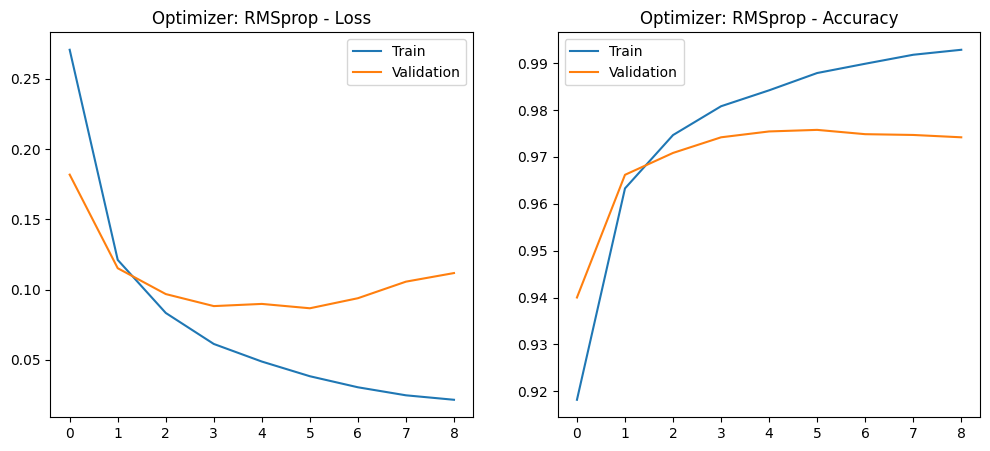


Training with Adam
Epoch 1: Train Loss=0.3172, Val Loss=0.1556, Train Acc=0.9076, Val Acc=0.9543
Epoch 2: Train Loss=0.1323, Val Loss=0.1161, Train Acc=0.9606, Val Acc=0.9656
Epoch 3: Train Loss=0.0890, Val Loss=0.0990, Train Acc=0.9723, Val Acc=0.9693
Epoch 4: Train Loss=0.0649, Val Loss=0.0915, Train Acc=0.9798, Val Acc=0.9743
Epoch 5: Train Loss=0.0518, Val Loss=0.0928, Train Acc=0.9839, Val Acc=0.9738
Epoch 6: Train Loss=0.0403, Val Loss=0.0969, Train Acc=0.9868, Val Acc=0.9713
Epoch 7: Train Loss=0.0338, Val Loss=0.1047, Train Acc=0.9888, Val Acc=0.9728
Early stopping triggered.


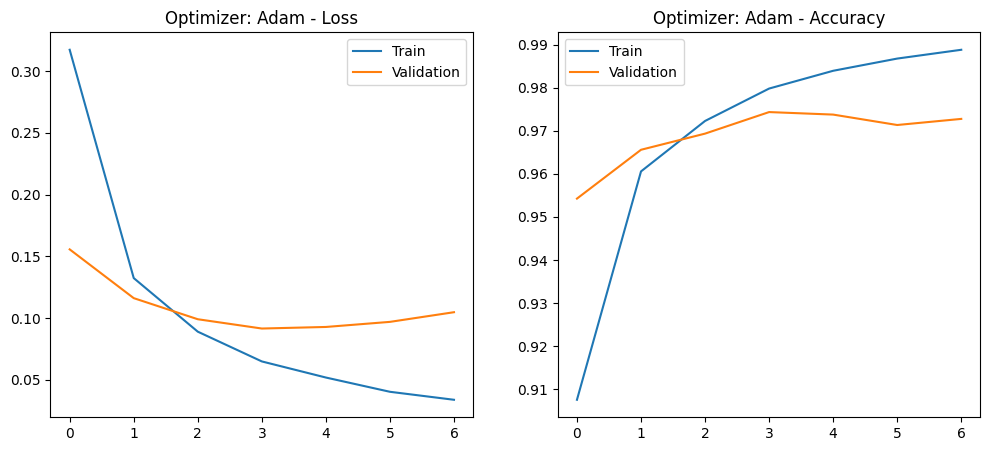

In [9]:
optimizers = {
    "SGD": optim.SGD,
    "RMSprop": optim.RMSprop,
    "Adam": optim.Adam
}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}")
    model = BaseModel()

    if name == "SGD":
        optimizer = opt(model.parameters(), lr=0.01)
    else:
        optimizer = opt(model.parameters(), lr=0.001)

    results = train_model(model, optimizer)
    plot_curves(*results, f"Optimizer: {name}")


## Step 8: Regularization (Dropout + Weight Decay)

In [10]:
class DropoutModel(nn.Module):
    def __init__(self):
        super(DropoutModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


Epoch 1: Train Loss=0.6056, Val Loss=0.2321, Train Acc=0.8131, Val Acc=0.9331
Epoch 2: Train Loss=0.3379, Val Loss=0.1700, Train Acc=0.9053, Val Acc=0.9527
Epoch 3: Train Loss=0.2895, Val Loss=0.1475, Train Acc=0.9186, Val Acc=0.9592
Epoch 4: Train Loss=0.2619, Val Loss=0.1340, Train Acc=0.9252, Val Acc=0.9610
Epoch 5: Train Loss=0.2432, Val Loss=0.1258, Train Acc=0.9306, Val Acc=0.9649
Epoch 6: Train Loss=0.2318, Val Loss=0.1229, Train Acc=0.9335, Val Acc=0.9654
Epoch 7: Train Loss=0.2210, Val Loss=0.1207, Train Acc=0.9365, Val Acc=0.9662
Epoch 8: Train Loss=0.2150, Val Loss=0.1203, Train Acc=0.9391, Val Acc=0.9645
Epoch 9: Train Loss=0.2083, Val Loss=0.1076, Train Acc=0.9400, Val Acc=0.9691
Epoch 10: Train Loss=0.1993, Val Loss=0.1125, Train Acc=0.9425, Val Acc=0.9687
Epoch 11: Train Loss=0.1961, Val Loss=0.1080, Train Acc=0.9432, Val Acc=0.9688
Epoch 12: Train Loss=0.1954, Val Loss=0.1042, Train Acc=0.9411, Val Acc=0.9692
Epoch 13: Train Loss=0.1889, Val Loss=0.1053, Train Acc=0.945

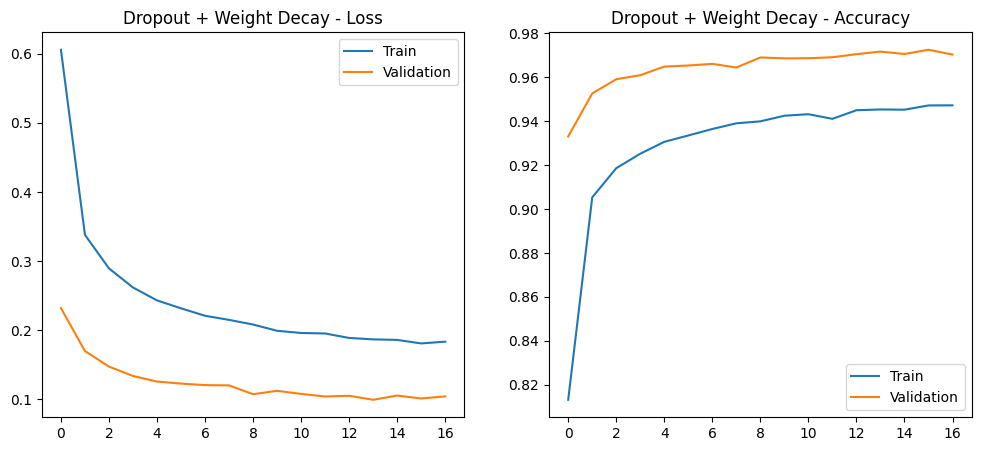

In [11]:
model = DropoutModel()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

results = train_model(model, optimizer)
plot_curves(*results, "Dropout + Weight Decay")


## Step 9: Test Set Evaluation

In [12]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {accuracy*100:.2f}%")


Test Accuracy: 97.04%


## Step 10: Confusion Matrix

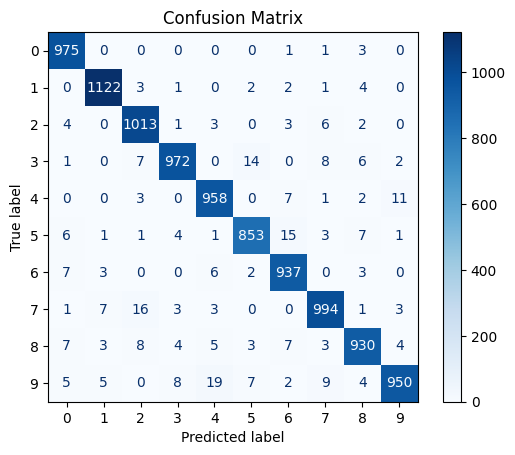

In [13]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


## Step 11: Prediction Visualization



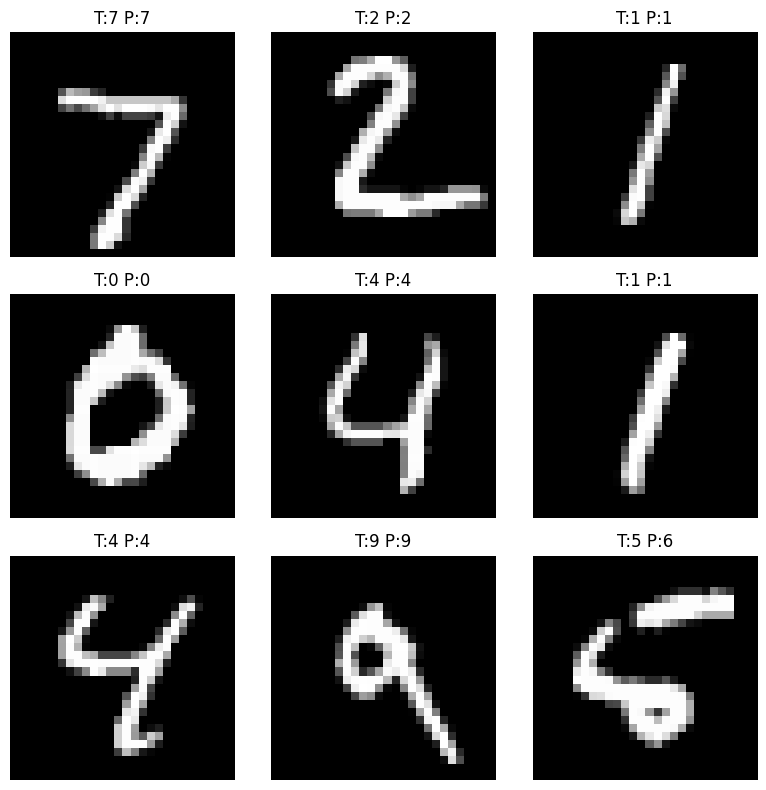

In [14]:
images, labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"T:{labels[i].item()} P:{predicted[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Final Observations

- Simple model underfits due to low capacity.
- Complex model shows signs of overfitting.
- Base model provides balanced performance.
- Adam optimizer converges fastest.
- Dropout and weight decay reduce overfitting.
- Early stopping prevents unnecessary training.

The final optimized model generalizes well to unseen test data.
